# spatial multi-omics alignment for mouse brain sections

Tutorial 3: spatial multi-omics alignment without paired images (omic-to-omic)

## 1. Load package and data paths

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import cv2
try:
    START_DIR = Path(__file__).resolve().parent
except NameError:
    START_DIR = Path.cwd()

PROJECT_ROOT = next(
    candidate for candidate in (START_DIR, *START_DIR.parents)
    if (candidate / "SPOmiAlign").is_dir()
)
spomialign_path = PROJECT_ROOT / "SPOmiAlign"
if str(spomialign_path) not in sys.path:
    sys.path.insert(0, str(spomialign_path))

from tutorial_utils import (
    generate_ssi_visualization,
    get_tutorial_paths,
    run_omic_to_omic_alignment,
    run_reassignment,
    read_bgr,
)

DATA_DIR, OUTPUT_ROOT = get_tutorial_paths(PROJECT_ROOT)
%matplotlib inline

✅ Successfully imported 'rasterize_h5ad_to_image' from data_process.py
Data directory: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/Data
Output directory: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output


## 2. Parameter settings

| Parameter | Meaning |
| --- | --- |
| `target_section_path` | reference ST h5ad path in `Data/`. |
| `source_section_path` | source SM h5ad path relative to `Data/`. |
| `target_rotate` / `source_rotate` | Clockwise manual rotation applied when rendering the target/source h5ad into SSI. |
| `SPOT` | Spot shape (`square` / `circle`) and visualization radius. |
| `Alignment_mode` | SPOmiAlign supports three alignment modes: Rigid (`Rigid`), Affine (`Affine`, `Homography`), and Non-Rigid (`bspline`, `affine+bspline`). |
| `device` | Torch device used by alignment, for example `cuda:0`, `cuda:1`, or `cpu`; `None` keeps automatic selection. |


In [2]:
DATA_PARAMS = {
    "target_section_path": 'Tutorial 3 spatial multi-omics alignment without paired images(omic-to-omic)/st_withIntensity.h5ad',
    "source_section_path": 'Tutorial 3 spatial multi-omics alignment without paired images(omic-to-omic)/sm_withIntensity.h5ad',
}

SSI_PARAMS = {
    "target_rotate": 0.0,
    "source_rotate": 60.0,
    "SPOT": {"shape": "square", "target_radius": 15, "source_radius": 12},
}

ALIGNMENT_PARAMS = {
    "sample_id": "sm2st1",
    "Alignment_mode": "affine+bspline",
    "device": "cuda:1",
}
DATA_PARAMS, SSI_PARAMS, ALIGNMENT_PARAMS

({'target_section_path': 'Tutorial 3 spatial multi-omics alignment without paired images(omic-to-omic)/st_withIntensity.h5ad',
  'source_section_path': 'Tutorial 3 spatial multi-omics alignment without paired images(omic-to-omic)/sm_withIntensity.h5ad'},
 {'target_rotate': 0.0,
  'source_rotate': 60.0,
  'SPOT': {'shape': 'square', 'target_radius': 15, 'source_radius': 12}},
 {'sample_id': 'sm2st1',
  'Alignment_mode': 'affine+bspline',
  'device': 'cuda:1'})

## 3. Generate SSI images

The target and source h5ad files are rendered as SSI images before matching. Coordinates are read from `obsm['spatial']`, and spot intensity is computed from expression counts in `X` by default.

[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/rendering/st_section_visualization.png (2200x2199, background=white, shape=square, points=1677)
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/rendering/sm_section_visualization.png (2186x2200, background=white, shape=square, points=3908)


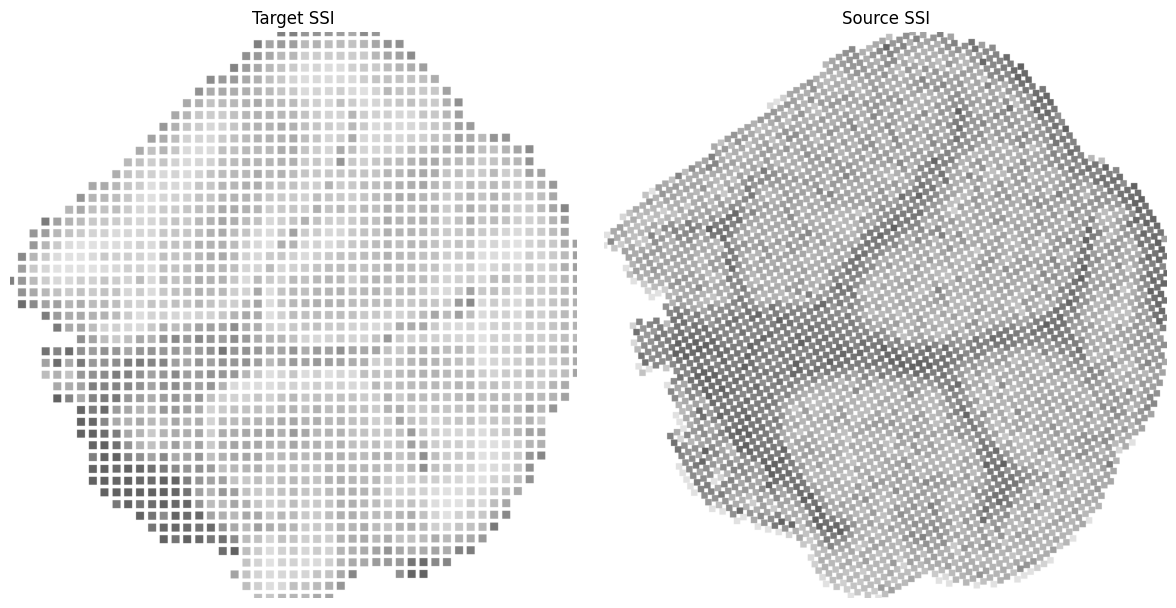

In [3]:
target_h5ad = DATA_DIR / DATA_PARAMS["target_section_path"]
source_h5ad = DATA_DIR / DATA_PARAMS["source_section_path"]

target_ssi = generate_ssi_visualization(
    output_root=OUTPUT_ROOT,
    sample_id=ALIGNMENT_PARAMS["sample_id"],
    h5ad_path=target_h5ad,
    label="target/ST",
    output_name="st_section_visualization.png",
    rotate=SSI_PARAMS["target_rotate"],
    SPOT={"shape": SSI_PARAMS["SPOT"]["shape"], "radius": SSI_PARAMS["SPOT"]["target_radius"]},
)
source_ssi = generate_ssi_visualization(
    output_root=OUTPUT_ROOT,
    sample_id=ALIGNMENT_PARAMS["sample_id"],
    h5ad_path=source_h5ad,
    label="source/SM",
    output_name="sm_section_visualization.png",
    rotate=SSI_PARAMS["source_rotate"],
    SPOT={"shape": SSI_PARAMS["SPOT"]["shape"], "radius": SSI_PARAMS["SPOT"]["source_radius"]},
)




images=[target_ssi["section_visualization"], source_ssi["section_visualization"]]
titles=["Target SSI", "Source SSI"]
figsize=(12, 6)
titles = titles or ["" for _ in images]
if figsize is None:
    figsize = (5.5 * len(images), 5.5)
fig, axes = plt.subplots(1, len(images), figsize=figsize)
if len(images) == 1:
    axes = [axes]
for ax, image_or_path, title in zip(axes, images, titles):
    image = read_bgr(image_or_path) if isinstance(image_or_path, (str, Path)) else image_or_path
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Run SPOmiAlign alignment

[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/rendering/st_section_visualization.png (2200x2199, background=white, shape=square, points=1677)
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/rendering/sm_section_visualization.png (2186x2200, background=white, shape=square, points=3908)
Using device: cuda:1


2026-05-11 12:11:48.774 | INFO     | romatch.models.model_zoo.roma_models:roma_model:61 - Using coarse resolution (560, 560), and upsample res (864, 1152)


Running RoMa matching...
Estimating affine+bspline transform...
Warping images...
Padding fill color: (255, 255, 255)
Processing H5AD coordinates...
[OK] Step 00 source coordinates mapped to render space: 3908/3908 points inside canvas -> /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/alignment/debug_step_00_source_in_render_space.png
📝 Columns not found or not specified. Updating adata.obsm['spatial']
[OK] Step 02 after resize to registration grid (source resized canvas): 3907/3908 points inside canvas -> /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/alignment/debug_step_02_after_resize_to_registration.png
📝 Columns not found or not specified. Updating adata.obsm['spatial']
[OK] Step 03 after registration transform (target resized canvas): 3907/3908 points inside canvas -> /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/alignment/debug_step_03_after_registration_transform.png
[OK] 

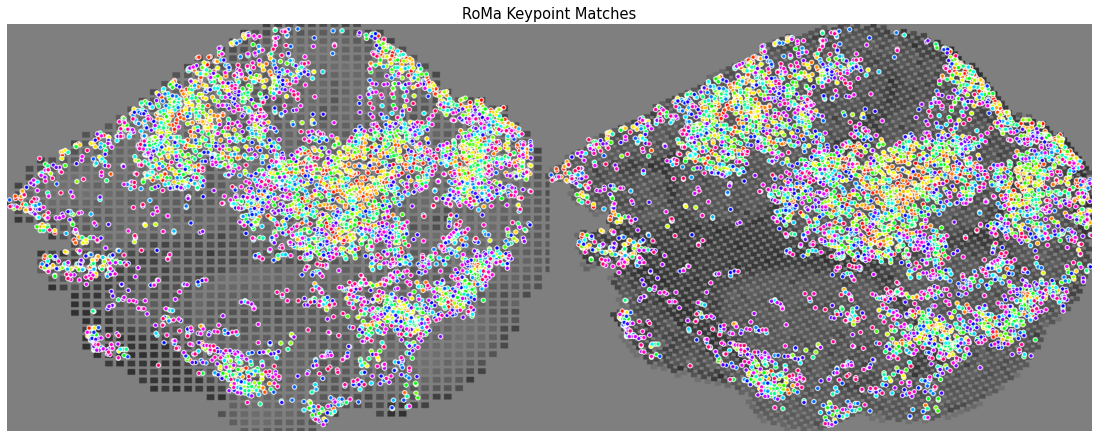

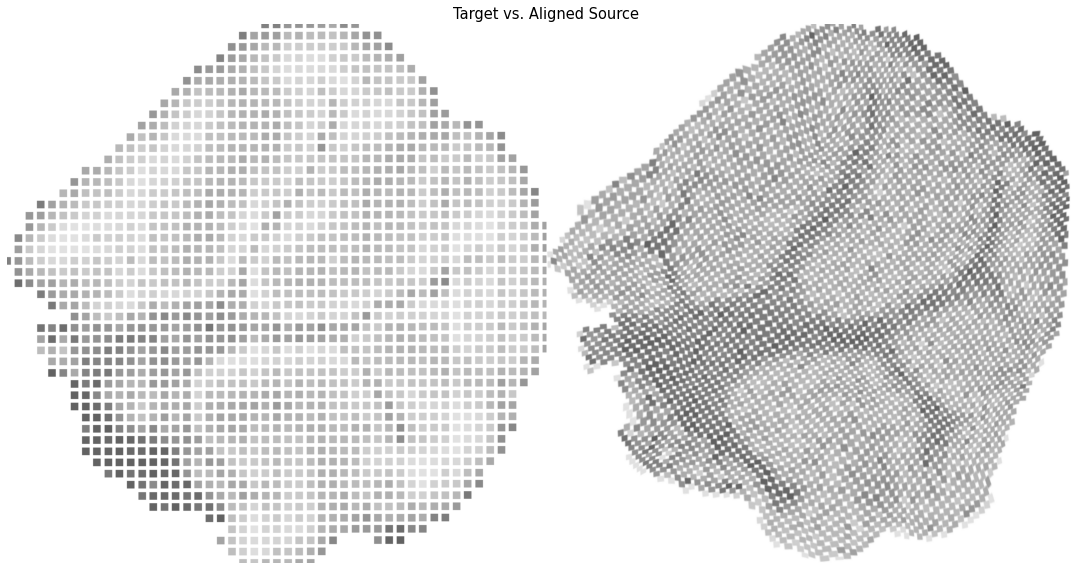

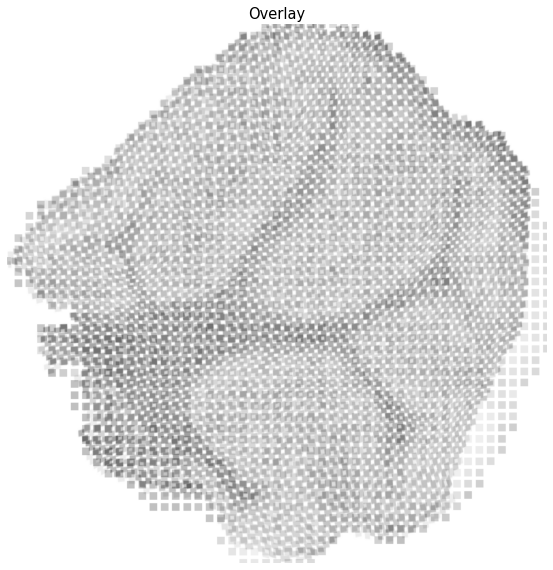

Alignment runtime: 6.3253 seconds
Done. Results saved to /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/alignment
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/alignment/transformed_sm_in_st_frame.png (2200x2199, background=white, shape=square, points=3908)


In [4]:
result = run_omic_to_omic_alignment(
    output_root=OUTPUT_ROOT,
    target_h5ad=target_h5ad,
    source_h5ad=source_h5ad,
    run_reassignment=False,
    **SSI_PARAMS,
    **ALIGNMENT_PARAMS,
)

## 5. Reassignment module

| Parameter | Meaning |
| --- | --- |
| `direction` | Reassignment direction; default is bidirectional, otherwise along this direction. |
| `s1_spatial_key` | Source coordinates produced by SPOmiAlign. |
| `s2_spatial_key` | Target coordinates used as the reference layout. |

In [5]:
REASSIGNMENT_PARAMS = {
    "direction": ("high_to_low","low_to_high"),
    "s1_spatial_key": "spatial_spomialign",
    "s2_spatial_key": "spatial_raw",
}

result.update(
    run_reassignment(
        output_root=OUTPUT_ROOT,
        sample_id=ALIGNMENT_PARAMS["sample_id"],
        target_h5ad=target_h5ad,
        source_h5ad=source_h5ad,
        aligned_source_h5ad=result["transformed_h5ad"],
        **REASSIGNMENT_PARAMS,
    )
)
result["high_to_low"], result["low_to_high"]


===== S1 UMI (spatial_spomialign) =====
value source: X.sum(axis=1)
n spots: 3908
x range: 1573.578 ~ 3580.643
y range: 1356.975 ~ 3420.575
value range: -197.535 ~ 394.225
value q1/q50/q99: -132.468, 9.919, 143.265
自动估计 spot_size = 27.48
✅ UMI 可视化已保存：/storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/high_to_low/plots/S1_umi.png

===== S2 UMI (spatial_raw) =====
value source: obs['total_counts']
n spots: 1677
x range: 1570.000 ~ 3647.000
y range: 1359.000 ~ 3435.000
value range: 3240.000 ~ 66513.000
value q1/q50/q99: 6507.800, 16556.000, 46400.560
自动估计 spot_size = 110.12
✅ UMI 可视化已保存：/storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/high_to_low/plots/S2_umi.png

开始构建 high_to_low 的新 h5ad ...
写出前 X 类型: <class 'numpy.ndarray'>
✅ 新 h5ad 已保存：/storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/high_to_low/reassigned_high_to_low_on_st.h5ad

===== Reassigned (high_to_low) UMI =====
value source: obs['

({'h5ad': PosixPath('/storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/high_to_low/reassigned_high_to_low_on_st.h5ad'),
  'mapping_csv': PosixPath('/storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/high_to_low/high_to_low_mapping.csv'),
  'plot_dir': PosixPath('/storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/high_to_low/plots'),
  'meta': {'low_res_name': 'S2',
   'high_res_name': 'S1',
   'd_ref_max': 44.0,
   'computed_d_ref_max': 44.0,
   'distance_multiplier': 2.0,
   'reassignment_direction': 'high_to_low',
   's1_spatial_key': 'spatial_spomialign',
   's2_spatial_key': 'spatial_raw',
   'scale_by_mapping_factor': True}},
 {'h5ad': PosixPath('/storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/low_to_high/reassigned_low_to_high_on_sm.h5ad'),
  'mapping_csv': PosixPath('/storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_h5ad/sm2st1/low_t

## 6. Outputs

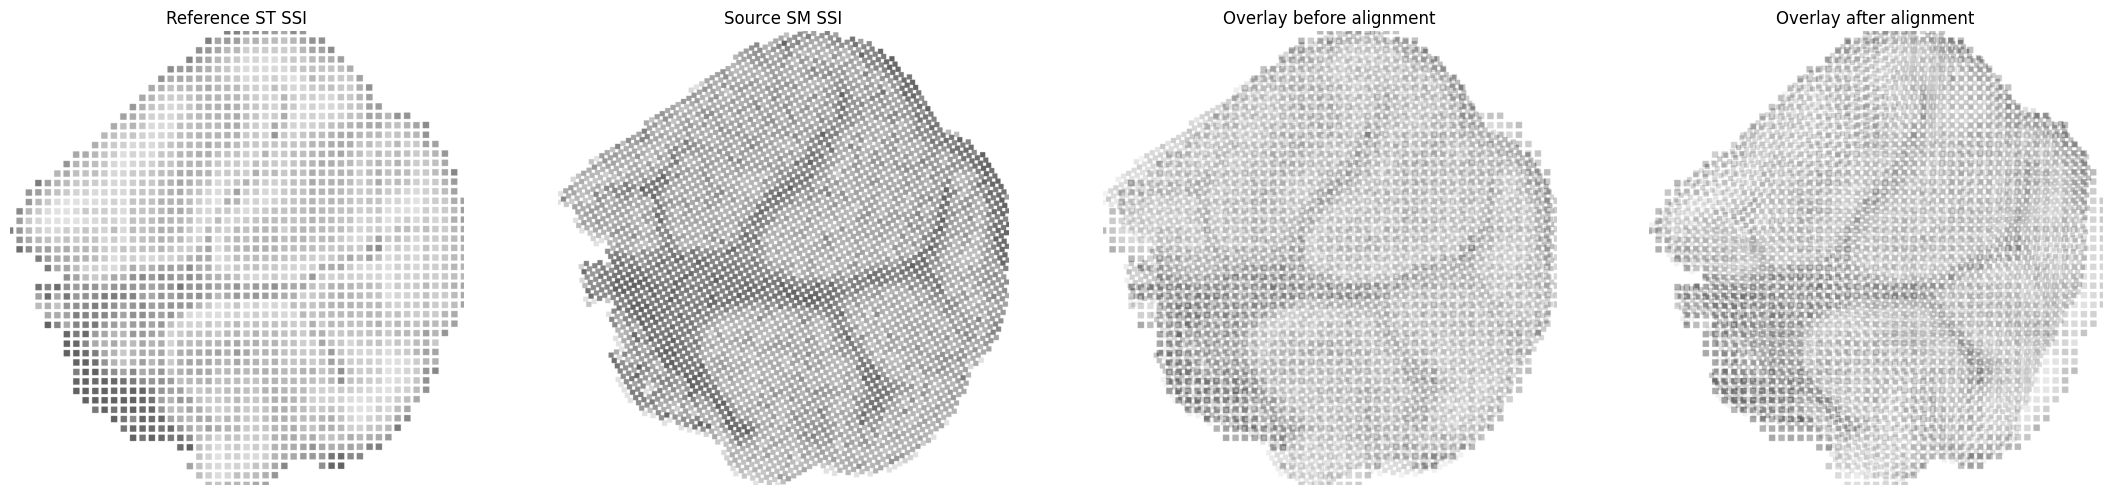

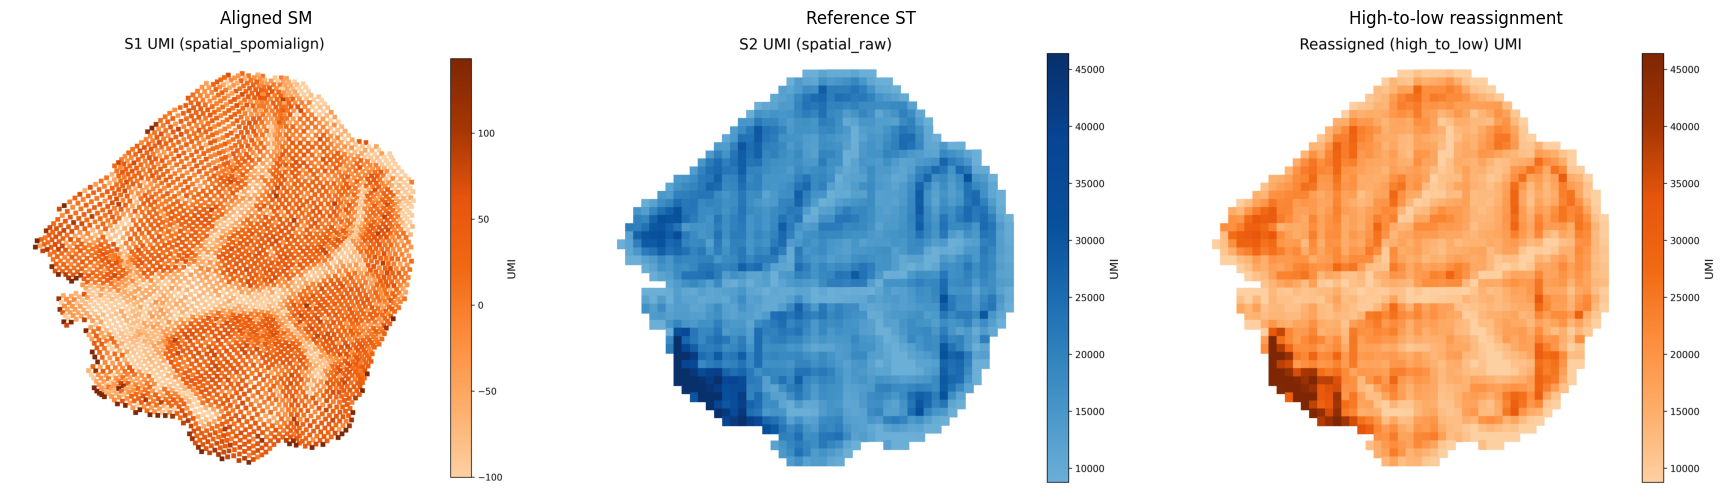

In [6]:
images=[result["target_section_visualization"], result["source_section_visualization"], result["before_overlay"], result["after_overlay"]]
titles=["Reference ST SSI", "Source SM SSI", "Overlay before alignment", "Overlay after alignment"]
figsize=(22, 5)
titles = titles or ["" for _ in images]
if figsize is None:
    figsize = (5.5 * len(images), 5.5)
fig, axes = plt.subplots(1, len(images), figsize=figsize)
if len(images) == 1:
    axes = [axes]
for ax, image_or_path, title in zip(axes, images, titles):
    image = read_bgr(image_or_path) if isinstance(image_or_path, (str, Path)) else image_or_path
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


images=[
        result["high_to_low"]["plot_dir"] / "S1_umi.png",
        result["high_to_low"]["plot_dir"] / "S2_umi.png",
        result["high_to_low"]["plot_dir"] / "reassigned_high_to_low_umi.png",
    ]
titles=["Aligned SM", "Reference ST", "High-to-low reassignment"]
figsize=(18, 5)
titles = titles or ["" for _ in images]
if figsize is None:
    figsize = (5.5 * len(images), 5.5)
fig, axes = plt.subplots(1, len(images), figsize=figsize)
if len(images) == 1:
    axes = [axes]
for ax, image_or_path, title in zip(axes, images, titles):
    image = read_bgr(image_or_path) if isinstance(image_or_path, (str, Path)) else image_or_path
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()